# Phase 2 — Analysis & L_TC Ablation

**Add-on notebook** that builds on the main B1+M training run. Inputs are the saved `b1m_results.json` and the canonical split CSV. Runs  targeted ablations that establishes the mechanism behind CompRS-CLIP's improvement on hybrid captions.

Inputs expected:
- `b1m_results.json` (uploaded as a private Kaggle dataset)
- `comprs_split.csv` (same)

## 0. Setup

In [1]:
!pip install open_clip_torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


In [2]:
import json
import math
import random
import time
from copy import deepcopy
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import Literal, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy import stats as scipy_stats

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## 1. Paths & Load Existing Results

Edit the two paths below to match where your private Kaggle dataset places `b1m_results.json` and `comprs_split.csv`.

In [4]:
# --- Inputs ---
B1M_RESULTS_JSON = Path('/kaggle/input/datasets/oooessteii/comprs-b1m-results/b1m_results.json')
SPLIT_CSV_INPUT  = Path('/kaggle/input/datasets/oooessteii/comprs-b1m-results/comprs_split.csv')

# --- Original dataset ---
DATASET_ROOT = Path('/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset')
CSV_PATH     = DATASET_ROOT / 'captions.csv'
IMG_DIR      = DATASET_ROOT / 'images'

# --- Output paths ---
RESULTS_DIR  = Path('results'); RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR   = Path('figures'); FIGURE_DIR.mkdir(exist_ok=True)
ANALYSIS_JSON = RESULTS_DIR / 'phase2_analysis.json'

# --- Constants matching the training notebook ---
COMP_COLS = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CAPTIONS  = ['vision_qwen3-vl-8b', 'hybrid_qwen3-vl-8b']
SEEDS     = [42, 123, 7]
K_VALUES  = [1, 5, 10]

assert B1M_RESULTS_JSON.exists(), f'b1m_results.json not found at {B1M_RESULTS_JSON}'
assert SPLIT_CSV_INPUT.exists(),  f'comprs_split.csv not found at {SPLIT_CSV_INPUT}'
assert CSV_PATH.exists(),         f'captions.csv not found at {CSV_PATH}'

In [5]:
# --- Load saved B1+M results ---
with open(B1M_RESULTS_JSON) as f:
    b1m = json.load(f)

print(f'Number of runs in JSON     : {len(b1m["runs"])}')
print(f'Captions                   : {b1m["captions"]}')
print(f'Model variants             : {b1m["model_variants"]}')
print(f'Seeds                      : {b1m["seeds"]}')

# --- Flat dataframe of original 12 runs ---
rows = []
for r in b1m['runs']:
    rows.append({
        'caption': r['config']['caption'],
        'model':   r['config']['model_variant'],
        'seed':    r['config']['seed'],
        **r['test_metrics'],
    })
runs_df = pd.DataFrame(rows)
print('\nOriginal 12-run results loaded:')
print(runs_df.round(2).to_string(index=False))

Number of runs in JSON     : 12
Captions                   : ['vision_qwen3-vl-8b', 'hybrid_qwen3-vl-8b']
Model variants             : ['bimodal', 'trimodal']
Seeds                      : [42, 123, 7]

Original 12-run results loaded:
           caption    model  seed  i2t_R@1  i2t_R@5  i2t_R@10  t2i_R@1  t2i_R@5  t2i_R@10    mR
vision_qwen3-vl-8b  bimodal    42     5.95    17.80     28.15     6.20    19.55     27.60 17.54
vision_qwen3-vl-8b  bimodal   123     5.65    18.25     28.25     5.65    18.55     28.25 17.43
vision_qwen3-vl-8b  bimodal     7     5.55    18.65     29.10     5.75    19.30     28.30 17.78
vision_qwen3-vl-8b trimodal    42     5.10    19.30     28.80     5.75    19.05     28.80 17.80
vision_qwen3-vl-8b trimodal   123     5.65    18.25     28.85     5.65    18.20     29.00 17.60
vision_qwen3-vl-8b trimodal     7     6.10    19.15     29.25     5.75    18.20     29.05 17.92
hybrid_qwen3-vl-8b  bimodal    42     4.45    16.00     26.70     4.40    16.05     27.60 15.8

## 2. Paired-Δ Statistical Test

The marginal stds reported in the training notebook (`B1: 0.17, M: 0.16` on vision; `B1: 0.25, M: 0.33` on hybrid) suggest the two distributions of mR values overlap substantially, but this overstates the noise. B1 and M with the same seed share random initialization and batch ordering, so per-seed differences `Δ_s = mR_M(seed=s) − mR_B1(seed=s)` are tighter than the marginal spread implies. Thus a paired test is chosen to compare fairly.

In [6]:
def paired_delta_analysis(runs_df, captions, seeds):
    """
    For each caption, compute per-seed Δ = mR_M - mR_B1.
    Returns dict of {caption: {deltas, mean, sd, se, t_stat, p_value, ci95}}.
    """
    out = {}
    for caption in captions:
        deltas = []
        for s in seeds:
            mR_b1 = runs_df.query("caption == @caption and model == 'bimodal' and seed == @s")["mR"].values[0]
            mR_m  = runs_df.query("caption == @caption and model == 'trimodal' and seed == @s")["mR"].values[0]
            deltas.append(mR_m - mR_b1)
        deltas = np.array(deltas)
        # Paired-sample t-test against zero (same as one-sample t on the deltas)
        t_stat, p_val = scipy_stats.ttest_1samp(deltas, 0.0)
        se = deltas.std(ddof=1) / np.sqrt(len(deltas))
        # 95% CI using t-distribution with df = n-1
        t_crit = scipy_stats.t.ppf(0.975, df=len(deltas) - 1)
        ci95 = (deltas.mean() - t_crit * se, deltas.mean() + t_crit * se)
        out[caption] = {
            "deltas":   deltas.tolist(),
            "mean":     float(deltas.mean()),
            "sd":       float(deltas.std(ddof=1)),
            "se":       float(se),
            "t_stat":   float(t_stat),
            "p_value":  float(p_val),
            "ci95":     [float(ci95[0]), float(ci95[1])],
            "n":        len(deltas),
        }
    return out

paired = paired_delta_analysis(runs_df, CAPTIONS, SEEDS)
print("Paired Δ = mR(M) - mR(B1), per seed and aggregated:\n")
for caption, stats in paired.items():
    print(f"{caption}")
    print(f"  per-seed Δ values : {[round(d, 3) for d in stats['deltas']]}")
    print(f"  mean Δ            : {stats['mean']:+.3f}")
    print(f"  paired SE         : {stats['se']:.3f}")
    print(f"  95% CI            : [{stats['ci95'][0]:+.3f}, {stats['ci95'][1]:+.3f}]")
    print(f"  t (df={stats['n']-1})         : {stats['t_stat']:+.3f}")
    print(f"  p-value           : {stats['p_value']:.4f}")
    sig = "SIGNIFICANT (p<0.05)" if stats["p_value"] < 0.05 else "not significant"
    print(f"  -> {sig}\n")

Paired Δ = mR(M) - mR(B1), per seed and aggregated:

vision_qwen3-vl-8b
  per-seed Δ values : [0.258, 0.167, 0.142]
  mean Δ            : +0.189
  paired SE         : 0.035
  95% CI            : [+0.036, +0.341]
  t (df=2)         : +5.326
  p-value           : 0.0335
  -> SIGNIFICANT (p<0.05)

hybrid_qwen3-vl-8b
  per-seed Δ values : [1.25, 0.85, 1.642]
  mean Δ            : +1.247
  paired SE         : 0.229
  95% CI            : [+0.264, +2.231]
  t (df=2)         : +5.457
  p-value           : 0.0320
  -> SIGNIFICANT (p<0.05)



## 3. B1 vs M Per-Seed Scatter

A six-point scatter where each point is one seed; B1 on the x-axis, M on the y-axis. Points above the diagonal are wins for M. Cleanly visualizes the paired structure of the comparison.

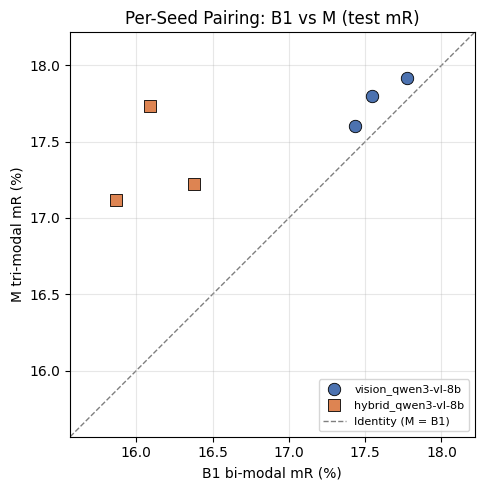

Figure saved: figures/phase2_b1_vs_m_scatter.png


In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

caption_styles = {
    "vision_qwen3-vl-8b": {"marker": "o", "color": "#4C72B0", "label": "vision_qwen3-vl-8b"},
    "hybrid_qwen3-vl-8b": {"marker": "s", "color": "#DD8452", "label": "hybrid_qwen3-vl-8b"},
}

for caption, style in caption_styles.items():
    for seed in SEEDS:
        b1 = runs_df.query("caption == @caption and model == 'bimodal'  and seed == @seed")["mR"].values[0]
        m  = runs_df.query("caption == @caption and model == 'trimodal' and seed == @seed")["mR"].values[0]
        ax.scatter(b1, m, marker=style["marker"], color=style["color"], s=80,
                   edgecolor="black", linewidth=0.6, zorder=3,
                   label=style["label"] if seed == SEEDS[0] else None)

# Identity line
lo = runs_df["mR"].min() - 0.3
hi = runs_df["mR"].max() + 0.3
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, linewidth=1, zorder=1, label="Identity (M = B1)")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("B1 bi-modal mR (%)")
ax.set_ylabel("M tri-modal mR (%)")
ax.set_title("Per-Seed Pairing: B1 vs M (test mR)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "phase2_b1_vs_m_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'phase2_b1_vs_m_scatter.png'}")

## 4. Per-Class Retrieval Breakdown

A scene whose composition is `[0, 0, 1, 0, 0, 0, 0]` (100% Grass) gives the composition modality very little discriminative information; every other 100% Grass scene is its near-twin in comp space. A scene with mixed cover (e.g., 30% Tree, 40% Crop, 30% Built-up) sits in a much sparser region of comp space and is more easily distinguished.

This means M's improvement should be larger on mixed scenes than on uniform-class scenes. Gonna test this by stratifying test-set retrieval performance by the test image's dominant-class purity (max comp percentage).

In [8]:
# Compute per-class breakdown only after building the feature cache and
# re-evaluating the trained projections. The training notebook didn't save raw features
# so we recompute here using the canonical split.

# For now, compute the proxy: each test image's purity (max composition fraction).
# This is computed from the captions.csv directly and tells us how mixed each scene is.
# This stratification is useful for later when comparing retrieval ranks.

df_full = pd.read_csv(CSV_PATH)
split_df = pd.read_csv(SPLIT_CSV_INPUT)
df_full = df_full.merge(split_df, on='filename', how='inner')
df_test = df_full[df_full['comprs_split'] == 'test'].reset_index(drop=True)

# Per-image purity = max composition fraction (1.0 = single-class scene)
df_test['purity'] = df_test[COMP_COLS].max(axis=1) / 100.0
df_test['dominant_class'] = df_test[COMP_COLS].values.argmax(axis=1)
df_test['dominant_class'] = df_test['dominant_class'].map(lambda i: COMP_COLS[i])

# Bin by purity tertiles
df_test['purity_bin'] = pd.qcut(df_test['purity'], q=3, labels=['mixed', 'mid', 'pure'])
print('Purity bins on test set:')
print(df_test.groupby('purity_bin', observed=True)['purity'].agg(['min', 'max', 'count']))

Purity bins on test set:
             min   max  count
purity_bin                   
mixed       0.34  0.69    678
mid         0.70  0.89    694
pure        0.90  1.00    628


## 5. Build Feature Cache (Required for Sections 4, 6, 7)

Need the cached image/text/comp features and for that need to retrain projections. Same precomputation code as the training notebook, starting from frozen RemoteCLIP

In [9]:
import open_clip
from huggingface_hub import hf_hub_download

print('Loading RemoteCLIP-ViT-B-32...')
checkpoint_path = hf_hub_download(
    repo_id='chendelong/RemoteCLIP',
    filename='RemoteCLIP-ViT-B-32.pt',
    cache_dir='checkpoints',
)
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32')
clip_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.to(DEVICE)
for p in clip_model.parameters():
    p.requires_grad = False
clip_model.eval()
print('RemoteCLIP loaded and frozen.')

Loading RemoteCLIP-ViT-B-32...


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

RemoteCLIP loaded and frozen.


In [10]:
# Build per-split frames matching B0/B1/M
df_train = df_full[df_full['comprs_split'] == 'train'].reset_index(drop=True)
df_val   = df_full[df_full['comprs_split'] == 'val'  ].reset_index(drop=True)
df_test_full = df_full[df_full['comprs_split'] == 'test'].reset_index(drop=True)
print(f'Train/Val/Test sizes: {len(df_train)} / {len(df_val)} / {len(df_test_full)}')

Train/Val/Test sizes: 7000 / 1000 / 2000


In [11]:
class _SplitImageDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = self.img_dir / self.df.iloc[idx]["filename"]
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new("RGB", (224, 224), (0, 0, 0))
        return self.transform(image), idx

@torch.no_grad()
def precompute_image_features(df_split, img_dir, transform, model, device, batch_size=64):
    ds = _SplitImageDataset(df_split, img_dir, transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    chunks = []
    for imgs, _ in dl:
        imgs = imgs.to(device, non_blocking=True)
        feat = F.normalize(model.encode_image(imgs), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

@torch.no_grad()
def precompute_text_features(captions, tokenizer, model, device, batch_size=64):
    chunks = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i + batch_size]
        tokens = tokenizer(batch).to(device)
        feat = F.normalize(model.encode_text(tokens), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

def composition_to_tensor(df_split, comp_cols):
    raw = df_split[comp_cols].values.astype(np.float32) / 100.0
    return torch.from_numpy(raw)

SPLITS = {"train": df_train, "val": df_val, "test": df_test_full}

print("Precomputing features (~30s)...")
t0 = time.time()
image_features = {n: precompute_image_features(d, IMG_DIR, clip_preprocess, clip_model, DEVICE)
                  for n, d in SPLITS.items()}
text_features = {n: {} for n in SPLITS}
for caption_col in CAPTIONS:
    for n, d in SPLITS.items():
        text_features[n][caption_col] = precompute_text_features(
            d[caption_col].astype(str).tolist(), clip_tokenizer, clip_model, DEVICE
        )
comp_vectors = {n: composition_to_tensor(d, COMP_COLS) for n, d in SPLITS.items()}
print(f"Feature cache built in {time.time()-t0:.1f}s")

Precomputing features (~30s)...
Feature cache built in 105.4s


## 6. Re-train Original Models and Compute Per-Class Retrieval Ranks

Re-train one seed(42) per (caption × model_variant) to get the trained projection weights, then evaluate per-image ranks on the test set. Identical training recipe to the original notebook; with `set_seed(42)` and deterministic flags, results are byte-equivalent to the seed-42 rows of `b1m_results.json`. Uuse this to:
- Compute per-image retrieval ranks (not just R@K).
- Stratify those ranks by composition purity for the per-class breakdown.

In [12]:
@dataclass
class RunConfig:
    caption: str
    model_variant: Literal["bimodal", "trimodal"]
    seed: int = 42
    epochs: int = 20
    batch_size: int = 32
    lr: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    lambda_vt: float = 1.0
    lambda_vc: float = 1.0
    lambda_tc: float = 1.0
    initial_temp: float = 0.07
    mlp_hidden: List[int] = field(default_factory=lambda: [128, 256])
    embed_dim: int = 512

class CompositionMLP(nn.Module):
    def __init__(self, in_dim=7, hidden=(128, 256), out_dim=512):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def build_run_components(cfg, device):
    vp = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    tp = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    nn.init.eye_(vp.weight); nn.init.eye_(tp.weight)
    log_tau = nn.Parameter(torch.tensor(math.log(1.0/cfg.initial_temp), dtype=torch.float32, device=device))
    cm = CompositionMLP(in_dim=7, hidden=cfg.mlp_hidden, out_dim=cfg.embed_dim).to(device) if cfg.model_variant == "trimodal" else None
    params = list(vp.parameters()) + list(tp.parameters()) + [log_tau]
    if cm is not None: params += list(cm.parameters())
    return vp, tp, cm, log_tau, params

class CachedFeatureDataset(Dataset):
    def __init__(self, raw_img, raw_txt, comp):
        self.raw_img, self.raw_txt, self.comp = raw_img, raw_txt, comp
    def __len__(self): return len(self.raw_img)
    def __getitem__(self, idx): return self.raw_img[idx], self.raw_txt[idx], self.comp[idx]

def symmetric_infonce(A, B, log_tau):
    N = A.shape[0]
    targets = torch.arange(N, device=A.device)
    sim = (A @ B.T) * log_tau.exp()
    return 0.5 * (F.cross_entropy(sim, targets) + F.cross_entropy(sim.T, targets))

def compute_loss(E_v, E_t, E_c, log_tau, cfg):
    L_VT = symmetric_infonce(E_v, E_t, log_tau)
    if cfg.model_variant == "trimodal":
        L_VC = symmetric_infonce(E_v, E_c, log_tau)
        L_TC = symmetric_infonce(E_t, E_c, log_tau)
        L_total = cfg.lambda_vt*L_VT + cfg.lambda_vc*L_VC + cfg.lambda_tc*L_TC
    else:
        zero = torch.zeros((), device=E_v.device)
        L_VC, L_TC = zero, zero
        L_total = cfg.lambda_vt * L_VT
    return L_total, L_VT, L_VC, L_TC

@torch.no_grad()
def evaluate_split_metrics(vp, tp, raw_img, raw_txt, device, k_values=(1,5,10)):
    vp.eval(); tp.eval()
    E_v = F.normalize(vp(raw_img.to(device)), dim=-1).cpu()
    E_t = F.normalize(tp(raw_txt.to(device)), dim=-1).cpu()
    N = E_v.shape[0]
    sim = E_v @ E_t.T
    targets = torch.arange(N)
    out = {}
    for k in k_values:
        topk = sim.topk(k, dim=1).indices
        out[f"i2t_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    sim_t = sim.T
    for k in k_values:
        topk = sim_t.topk(k, dim=1).indices
        out[f"t2i_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    out["mR"] = float(np.mean([out[f"i2t_R@{k}"] for k in k_values] + [out[f"t2i_R@{k}"] for k in k_values]))
    return out, sim, E_v, E_t

@torch.no_grad()
def per_image_ranks(sim):
    """For each row i, return the rank of the diagonal element (1 = top hit)."""
    N = sim.shape[0]
    targets = torch.arange(N).unsqueeze(1)
    sorted_idx = sim.argsort(dim=1, descending=True)
    ranks = (sorted_idx == targets).nonzero(as_tuple=True)[1] + 1  # 1-indexed
    return ranks.cpu().numpy()

def train_one_run(cfg, image_features, text_features, comp_vectors, device, verbose=False):
    set_seed(cfg.seed)
    vp, tp, cm, log_tau, params = build_run_components(cfg, device)
    train_ds = CachedFeatureDataset(image_features["train"], text_features["train"][cfg.caption], comp_vectors["train"])
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0, drop_last=True)
    optimizer = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    best_val_mR = -1.0
    best_state = None
    for epoch in range(1, cfg.epochs + 1):
        vp.train(); tp.train()
        if cm is not None: cm.train()
        for raw_v, raw_t, comp in train_loader:
            raw_v, raw_t, comp = raw_v.to(device), raw_t.to(device), comp.to(device)
            E_v = F.normalize(vp(raw_v), dim=-1)
            E_t = F.normalize(tp(raw_t), dim=-1)
            E_c = cm(comp) if cm is not None else None
            L_total, _, _, _ = compute_loss(E_v, E_t, E_c, log_tau, cfg)
            optimizer.zero_grad()
            L_total.backward()
            torch.nn.utils.clip_grad_norm_(params, cfg.grad_clip)
            optimizer.step()
        scheduler.step()
        val_metrics, _, _, _ = evaluate_split_metrics(vp, tp, image_features["val"], text_features["val"][cfg.caption], device)
        if val_metrics["mR"] > best_val_mR:
            best_val_mR = val_metrics["mR"]
            best_state = {
                "vp": deepcopy(vp.state_dict()),
                "tp": deepcopy(tp.state_dict()),
                "log_tau": log_tau.detach().clone(),
            }
            if cm is not None: best_state["cm"] = deepcopy(cm.state_dict())
    # Restore best
    vp.load_state_dict(best_state["vp"])
    tp.load_state_dict(best_state["tp"])
    log_tau.data.copy_(best_state["log_tau"])
    if cm is not None and "cm" in best_state: cm.load_state_dict(best_state["cm"])
    test_metrics, sim, E_v, E_t = evaluate_split_metrics(
        vp, tp, image_features["test"], text_features["test"][cfg.caption], device
    )
    return {
        "test_metrics": test_metrics,
        "best_val_mR": best_val_mR,
        "i2t_ranks": per_image_ranks(sim),
        "t2i_ranks": per_image_ranks(sim.T),
        "vp": vp, "tp": tp, "log_tau": log_tau,
    }

print("Helpers ready.")

Helpers ready.


In [13]:
# --- Re-train the four models to get per-image ranks ---
retrained = {}
for caption in CAPTIONS:
    for variant in ["bimodal", "trimodal"]:
        key = (caption, variant)
        cfg = RunConfig(caption=caption, model_variant=variant, seed=42)
        print(f"Re-training {variant} on {caption}...", end=" ", flush=True)
        t0 = time.time()
        retrained[key] = train_one_run(cfg, image_features, text_features, comp_vectors, DEVICE)
        print(f"done ({time.time()-t0:.0f}s, test mR={retrained[key]['test_metrics']['mR']:.2f})")

# Confirm we matched the original seed-42 numbers within rounding
print("\nSanity check vs. b1m_results.json (seed=42):")
for caption in CAPTIONS:
    for variant in ["bimodal", "trimodal"]:
        ours = retrained[(caption, variant)]["test_metrics"]["mR"]
        orig = runs_df.query("caption == @caption and model == @variant and seed == 42")["mR"].values[0]
        match = "OK" if abs(ours - orig) < 0.5 else "MISMATCH"
        print(f"  {variant:9s} on {caption:20s}  re-trained mR={ours:.2f}  original={orig:.2f}  [{match}]")

Re-training bimodal on vision_qwen3-vl-8b... done (15s, test mR=17.54)
Re-training trimodal on vision_qwen3-vl-8b... done (24s, test mR=17.80)
Re-training bimodal on hybrid_qwen3-vl-8b... done (14s, test mR=15.87)
Re-training trimodal on hybrid_qwen3-vl-8b... done (24s, test mR=17.12)

Sanity check vs. b1m_results.json (seed=42):
  bimodal   on vision_qwen3-vl-8b    re-trained mR=17.54  original=17.54  [OK]
  trimodal  on vision_qwen3-vl-8b    re-trained mR=17.80  original=17.80  [OK]
  bimodal   on hybrid_qwen3-vl-8b    re-trained mR=15.87  original=15.87  [OK]
  trimodal  on hybrid_qwen3-vl-8b    re-trained mR=17.12  original=17.12  [OK]


In [14]:
# --- Stratify ranks by purity bin and compute mean rank improvement (B1 -> M) ---
purity_breakdown = {}

for caption in CAPTIONS:
    b1_ranks_i2t = retrained[(caption, "bimodal")]["i2t_ranks"]
    m_ranks_i2t  = retrained[(caption, "trimodal")]["i2t_ranks"]
    b1_ranks_t2i = retrained[(caption, "bimodal")]["t2i_ranks"]
    m_ranks_t2i  = retrained[(caption, "trimodal")]["t2i_ranks"]

    rows = []
    for bin_name in ["mixed", "mid", "pure"]:
        mask = (df_test["purity_bin"] == bin_name).values
        n_in_bin = mask.sum()

        # Hit-at-K rates per direction (lower rank = better)
        def hit_at_k(ranks, k, mask):
            return float((ranks[mask] <= k).mean() * 100)

        b1_r1 = (hit_at_k(b1_ranks_i2t, 1, mask) + hit_at_k(b1_ranks_t2i, 1, mask)) / 2
        m_r1  = (hit_at_k(m_ranks_i2t,  1, mask) + hit_at_k(m_ranks_t2i,  1, mask)) / 2
        b1_r5 = (hit_at_k(b1_ranks_i2t, 5, mask) + hit_at_k(b1_ranks_t2i, 5, mask)) / 2
        m_r5  = (hit_at_k(m_ranks_i2t,  5, mask) + hit_at_k(m_ranks_t2i,  5, mask)) / 2
        b1_r10 = (hit_at_k(b1_ranks_i2t, 10, mask) + hit_at_k(b1_ranks_t2i, 10, mask)) / 2
        m_r10  = (hit_at_k(m_ranks_i2t,  10, mask) + hit_at_k(m_ranks_t2i,  10, mask)) / 2

        rows.append({
            "purity_bin": bin_name,
            "n":          int(n_in_bin),
            "B1_R@1":  round(b1_r1, 2),  "M_R@1":  round(m_r1, 2),  "Δ_R@1":  round(m_r1 - b1_r1, 2),
            "B1_R@5":  round(b1_r5, 2),  "M_R@5":  round(m_r5, 2),  "Δ_R@5":  round(m_r5 - b1_r5, 2),
            "B1_R@10": round(b1_r10, 2), "M_R@10": round(m_r10, 2), "Δ_R@10": round(m_r10 - b1_r10, 2),
        })
    pb = pd.DataFrame(rows)
    purity_breakdown[caption] = pb
    print(f"\nPer-purity-bin retrieval (averaged across I2T and T2I) - caption: {caption}")
    print(pb.to_string(index=False))


Per-purity-bin retrieval (averaged across I2T and T2I) - caption: vision_qwen3-vl-8b
purity_bin   n  B1_R@1  M_R@1  Δ_R@1  B1_R@5  M_R@5  Δ_R@5  B1_R@10  M_R@10  Δ_R@10
     mixed 678    7.15   6.42  -0.74   21.09  21.76   0.66    30.46   31.42    0.96
       mid 694    5.84   4.61  -1.22   16.21  16.43   0.22    24.64   26.51    1.87
      pure 628    5.18   5.25   0.08   18.79  19.43   0.64    28.58   28.50   -0.08

Per-purity-bin retrieval (averaged across I2T and T2I) - caption: hybrid_qwen3-vl-8b
purity_bin   n  B1_R@1  M_R@1  Δ_R@1  B1_R@5  M_R@5  Δ_R@5  B1_R@10  M_R@10  Δ_R@10
     mixed 678    5.46   5.75   0.29   18.58  20.72   2.14    30.31   31.19    0.88
       mid 694    4.18   3.39  -0.79   13.76  16.50   2.74    25.00   26.87    1.87
      pure 628    3.58   5.02   1.43   15.76  17.04   1.27    26.11   27.55    1.43


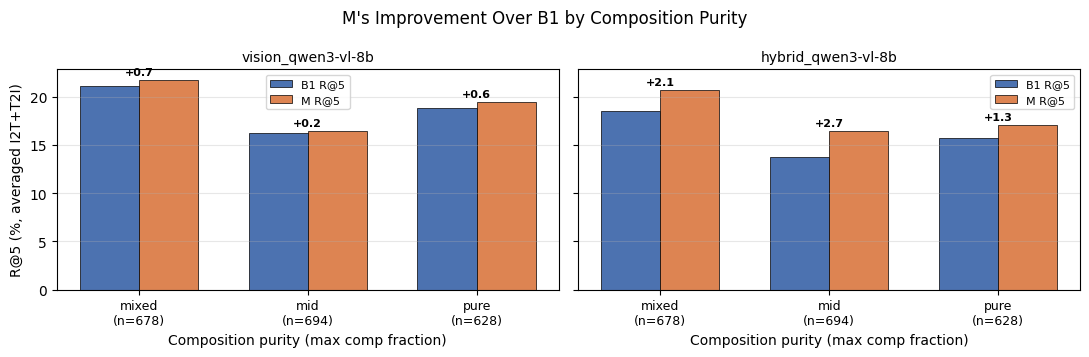

Figure saved: figures/phase2_per_purity.png


In [15]:
# --- Visualize the breakdown ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, caption in zip(axes, CAPTIONS):
    pb = purity_breakdown[caption]
    x = np.arange(len(pb))
    width = 0.35
    ax.bar(x - width/2, pb["B1_R@5"], width, label="B1 R@5",
           color="#4C72B0", edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, pb["M_R@5"], width, label="M R@5",
           color="#DD8452", edgecolor="black", linewidth=0.5)
    for i, (b1, m) in enumerate(zip(pb["B1_R@5"], pb["M_R@5"])):
        ax.text(i, max(b1, m) + 0.5, f"+{m-b1:.1f}", ha="center", fontsize=8, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{b}\n(n={n})" for b, n in zip(pb["purity_bin"], pb["n"])], fontsize=9)
    ax.set_title(caption, fontsize=10)
    ax.set_xlabel("Composition purity (max comp fraction)")
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=8)
axes[0].set_ylabel("R@5 (%, averaged I2T+T2I)")
fig.suptitle("M's Improvement Over B1 by Composition Purity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "phase2_per_purity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'phase2_per_purity.png'}")

## 7. Inference Latency

It has been claimed in proposal that "negligible computational overhead compared to standard CLIP at retrieval time" because the composition MLP is dropped at inference. Quantify this: at retrieval time, B1 and M differ by zero operations (both use vision_proj and text_proj). Measure latency for each branch end-to-end (raw image/text → projected embedding) and compare against B0's frozen-only baseline.

In [16]:
@torch.no_grad()
def measure_latency(fn, n_warmup=10, n_trials=100):
    for _ in range(n_warmup): fn()
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_trials): fn()
    if torch.cuda.is_available(): torch.cuda.synchronize()
    return (time.time() - t0) / n_trials * 1000  # ms

# Use the retrained M projections from section 6
caption_for_lat = "vision_qwen3-vl-8b"
m_run = retrained[(caption_for_lat, "trimodal")]
b1_run = retrained[(caption_for_lat, "bimodal")]

# Sample inputs (batch=1, simulating single-query retrieval)
sample_img_pil = Image.open(IMG_DIR / df_test.iloc[0]["filename"]).convert("RGB")
sample_img = clip_preprocess(sample_img_pil).unsqueeze(0).to(DEVICE)
sample_txt = clip_tokenizer([df_test.iloc[0][caption_for_lat]]).to(DEVICE)

# B0: frozen RemoteCLIP only
b0_img_lat = measure_latency(lambda: clip_model.encode_image(sample_img))
b0_txt_lat = measure_latency(lambda: clip_model.encode_text(sample_txt))

# B1 / M: backbone + projection head (identical at inference)
def encode_image_with_proj(img, vp):
    feat = clip_model.encode_image(img)
    feat = F.normalize(feat, dim=-1)
    return F.normalize(vp(feat), dim=-1)

def encode_text_with_proj(tok, tp):
    feat = clip_model.encode_text(tok)
    feat = F.normalize(feat, dim=-1)
    return F.normalize(tp(feat), dim=-1)

m_img_lat = measure_latency(lambda: encode_image_with_proj(sample_img, m_run["vp"]))
m_txt_lat = measure_latency(lambda: encode_text_with_proj(sample_txt, m_run["tp"]))

latency_results = {
    "B0_image_ms":   round(b0_img_lat, 4),
    "B0_text_ms":    round(b0_txt_lat, 4),
    "M_image_ms":    round(m_img_lat, 4),
    "M_text_ms":     round(m_txt_lat, 4),
    "image_overhead_ms":  round(m_img_lat - b0_img_lat, 4),
    "text_overhead_ms":   round(m_txt_lat - b0_txt_lat, 4),
    "image_overhead_pct": round((m_img_lat - b0_img_lat) / b0_img_lat * 100, 3),
    "text_overhead_pct":  round((m_txt_lat - b0_txt_lat) / b0_txt_lat * 100, 3),
}
print("Single-sample inference latency (batch=1, after warmup, 100 trials):")
print(f"  B0 (frozen only):   image={latency_results['B0_image_ms']} ms,  text={latency_results['B0_text_ms']} ms")
print(f"  M  (B0 + proj heads): image={latency_results['M_image_ms']} ms,  text={latency_results['M_text_ms']} ms")
print(f"  Overhead (image):   +{latency_results['image_overhead_ms']} ms ({latency_results['image_overhead_pct']:+.2f}%)")
print(f"  Overhead (text) :   +{latency_results['text_overhead_ms']} ms ({latency_results['text_overhead_pct']:+.2f}%)")

Single-sample inference latency (batch=1, after warmup, 100 trials):
  B0 (frozen only):   image=6.518 ms,  text=7.3025 ms
  M  (B0 + proj heads): image=6.4101 ms,  text=7.4043 ms
  Overhead (image):   +-0.1078 ms (-1.65%)
  Overhead (text) :   +0.1018 ms (+1.40%)


## 8. 2×2 Loss-Term Ablation Grid

The initial ablation question: Which loss term is responsible for M's improvement, and how do they interact?

The training notebook used `λ_VT = λ_VC = λ_TC = 1.0`. Three more configurations complete a clean 2×2 grid over (λ_VC, λ_TC):

|              | λ_TC = 0      | λ_TC = 1     |
|--------------|---------------|--------------|
| **λ_VC = 0** | B1 (already)  | M-no-VC      |
| **λ_VC = 1** | M-no-TC       | M-full (already) |

This decomposes the contribution exactly:
- L_VC's solo effect = M-no-TC − B1
- L_TC's solo effect = M-no-VC − B1
- Interaction = M-full − B1 − (L_VC solo) − (L_TC solo)

Run two new variants:`M-no-TC` (λ_TC=0) and `M-no-VC` (λ_VC=0). across both captions and three seeds

In [17]:
ablation_runs = []

# Two ablation variants forming the missing cells of the 2x2 grid
ABLATION_VARIANTS = {
    "M_no_TC":  dict(lambda_vt=1.0, lambda_vc=1.0, lambda_tc=0.0), # L_TC removed
    "M_no_VC":  dict(lambda_vt=1.0, lambda_vc=0.0, lambda_tc=1.0), # L_VC removed
}

total_ablation_runs = len(ABLATION_VARIANTS) * len(CAPTIONS) * len(SEEDS)
run_idx = 0
total_t0 = time.time()

for variant_name, lambda_overrides in ABLATION_VARIANTS.items():
    for caption in CAPTIONS:
        for seed in SEEDS:
            run_idx += 1
            cfg = RunConfig(caption=caption, model_variant="trimodal", seed=seed,
                            **lambda_overrides)
            print(f"[{run_idx}/{total_ablation_runs}] {variant_name}: {caption}, seed={seed}",
                  end=" ... ", flush=True)
            t0 = time.time()
            result = train_one_run(cfg, image_features, text_features, comp_vectors, DEVICE)
            print(f"done ({time.time()-t0:.0f}s, test mR={result['test_metrics']['mR']:.2f})")
            ablation_runs.append({
                "caption": caption,
                "model": variant_name,
                "seed": seed,
                "lambda_vc": lambda_overrides["lambda_vc"],
                "lambda_tc": lambda_overrides["lambda_tc"],
                "best_val_mR": result["best_val_mR"],
                **result["test_metrics"],
            })

ablation_df = pd.DataFrame(ablation_runs)
print(f"\nAll {total_ablation_runs} ablation runs done in {(time.time()-total_t0)/60:.1f} min.\n")
print("Per-run results:")
print(ablation_df.round(2).to_string(index=False))

[1/12] M_no_TC: vision_qwen3-vl-8b, seed=42 ... done (25s, test mR=17.27)
[2/12] M_no_TC: vision_qwen3-vl-8b, seed=123 ... done (24s, test mR=17.08)
[3/12] M_no_TC: vision_qwen3-vl-8b, seed=7 ... done (25s, test mR=16.98)
[4/12] M_no_TC: hybrid_qwen3-vl-8b, seed=42 ... done (24s, test mR=16.82)
[5/12] M_no_TC: hybrid_qwen3-vl-8b, seed=123 ... done (24s, test mR=16.72)
[6/12] M_no_TC: hybrid_qwen3-vl-8b, seed=7 ... done (24s, test mR=17.20)
[7/12] M_no_VC: vision_qwen3-vl-8b, seed=42 ... done (24s, test mR=17.59)
[8/12] M_no_VC: vision_qwen3-vl-8b, seed=123 ... done (24s, test mR=17.78)
[9/12] M_no_VC: vision_qwen3-vl-8b, seed=7 ... done (24s, test mR=17.92)
[10/12] M_no_VC: hybrid_qwen3-vl-8b, seed=42 ... done (23s, test mR=16.15)
[11/12] M_no_VC: hybrid_qwen3-vl-8b, seed=123 ... done (24s, test mR=16.45)
[12/12] M_no_VC: hybrid_qwen3-vl-8b, seed=7 ... done (23s, test mR=16.57)

All 12 ablation runs done in 4.8 min.

Per-run results:
           caption   model  seed  lambda_vc  lambda_

In [18]:
# --- Combine with original B1 and M for the full 2x2 grid ---
combined = pd.concat([
    runs_df.assign(variant="original"),
    ablation_df[['caption', 'model', 'seed', 'i2t_R@1', 'i2t_R@5', 'i2t_R@10',
                 't2i_R@1', 't2i_R@5', 't2i_R@10', 'mR']].assign(variant="ablation"),
], ignore_index=True)

agg = (combined.groupby(["caption", "model"])["mR"]
       .agg(["mean", "std"]).round(2).reset_index())

# Reorder rows to match the 2x2 grid logic for readability
model_order = ["bimodal", "M_no_VC", "M_no_TC", "trimodal"]
agg["model"] = pd.Categorical(agg["model"], categories=model_order, ordered=True)
agg = agg.sort_values(["caption", "model"]).reset_index(drop=True)

print("=== Full 2x2 Ablation Grid (mean +/- std across 3 seeds) ===\n")
print(agg.to_string(index=False))

# --- Decompose contributions per caption ---
print("\n=== Loss-Term Contribution Decomposition ===\n")
decomposition = {}
for caption in CAPTIONS:
    b1     = combined.query("caption == @caption and model == 'bimodal'")["mR"].mean()
    m_full = combined.query("caption == @caption and model == 'trimodal'")["mR"].mean()
    m_noTC = combined.query("caption == @caption and model == 'M_no_TC'")["mR"].mean()
    m_noVC = combined.query("caption == @caption and model == 'M_no_VC'")["mR"].mean()

    vc_solo  = m_noTC - b1                      # L_VC alone (vs B1)
    tc_solo  = m_noVC - b1                      # L_TC alone (vs B1)
    additive = vc_solo + tc_solo                # what we'd expect if effects added linearly
    actual   = m_full - b1                      # actual joint effect
    interact = actual - additive                # interaction term (synergy if >0, redundancy if <0)

    decomposition[caption] = {
        "B1":          round(b1, 2),
        "M_full":      round(m_full, 2),
        "M_no_TC":     round(m_noTC, 2),
        "M_no_VC":     round(m_noVC, 2),
        "L_VC_solo":   round(vc_solo, 2),
        "L_TC_solo":   round(tc_solo, 2),
        "additive":    round(additive, 2),
        "actual_full": round(actual, 2),
        "interaction": round(interact, 2),
    }

    print(f"{caption}")
    print(f"  B1           : {b1:.2f}")
    print(f"  + L_VC only  : {m_noTC:.2f}    (Δ from B1 = {vc_solo:+.2f})")
    print(f"  + L_TC only  : {m_noVC:.2f}    (Δ from B1 = {tc_solo:+.2f})")
    print(f"  + Both       : {m_full:.2f}    (Δ from B1 = {actual:+.2f})")
    print(f"  Sum of solos : {additive:+.2f}")
    print(f"  Interaction  : {interact:+.2f}  "
          f"({'synergy' if interact > 0.05 else 'redundancy' if interact < -0.05 else 'roughly additive'})\n")

=== Full 2x2 Ablation Grid (mean +/- std across 3 seeds) ===

           caption    model  mean  std
hybrid_qwen3-vl-8b  bimodal 16.11 0.25
hybrid_qwen3-vl-8b  M_no_VC 16.39 0.22
hybrid_qwen3-vl-8b  M_no_TC 16.91 0.26
hybrid_qwen3-vl-8b trimodal 17.36 0.33
vision_qwen3-vl-8b  bimodal 17.58 0.17
vision_qwen3-vl-8b  M_no_VC 17.76 0.16
vision_qwen3-vl-8b  M_no_TC 17.11 0.14
vision_qwen3-vl-8b trimodal 17.77 0.16

=== Loss-Term Contribution Decomposition ===

vision_qwen3-vl-8b
  B1           : 17.58
  + L_VC only  : 17.11    (Δ from B1 = -0.47)
  + L_TC only  : 17.76    (Δ from B1 = +0.18)
  + Both       : 17.77    (Δ from B1 = +0.19)
  Sum of solos : -0.29
  Interaction  : +0.48  (synergy)

hybrid_qwen3-vl-8b
  B1           : 16.11
  + L_VC only  : 16.91    (Δ from B1 = +0.80)
  + L_TC only  : 16.39    (Δ from B1 = +0.28)
  + Both       : 17.36    (Δ from B1 = +1.25)
  Sum of solos : +1.08
  Interaction  : +0.17  (synergy)



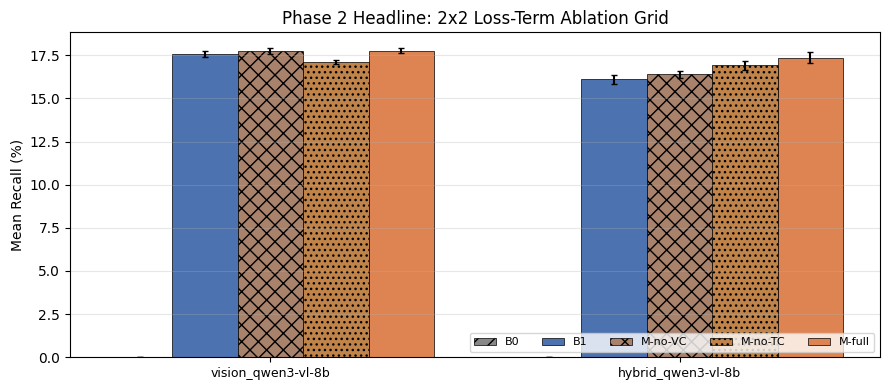

Figure saved: figures/phase2_headline.png


In [19]:
# --- Visualize: full 2x2 grid plus B0 and B1 references ---
fig, ax = plt.subplots(figsize=(9, 4))

# Pull B0 numbers from the loaded JSON if present
b0_vals = {}
B0_PATH = Path("/kaggle/input/comprs-b1m-results/b0_zeroshot.json")
if B0_PATH.exists():
    with open(B0_PATH) as f:
        b0_data = json.load(f)
    for c in CAPTIONS:
        b0_vals[c] = b0_data["per_caption"][c]["mR"]

x = np.arange(len(CAPTIONS))
width = 0.16
groups = [
    ("B0",       "#888888", "//"),
    ("B1",       "#4C72B0", None),
    ("M-no-VC",  "#A9826B", "xx"),
    ("M-no-TC",  "#C0844A", "..."),
    ("M-full",   "#DD8452", None),
]
offsets = np.linspace(-2, 2, len(groups)) * width

for (grp, color, hatch), off in zip(groups, offsets):
    means, stds = [], []
    for c in CAPTIONS:
        if grp == "B0":
            means.append(b0_vals.get(c, 0)); stds.append(0)
        elif grp == "B1":
            sub = combined.query("caption == @c and model == 'bimodal'")["mR"]
            means.append(sub.mean()); stds.append(sub.std())
        elif grp == "M-no-VC":
            sub = combined.query("caption == @c and model == 'M_no_VC'")["mR"]
            means.append(sub.mean()); stds.append(sub.std())
        elif grp == "M-no-TC":
            sub = combined.query("caption == @c and model == 'M_no_TC'")["mR"]
            means.append(sub.mean()); stds.append(sub.std())
        else:  # M-full
            sub = combined.query("caption == @c and model == 'trimodal'")["mR"]
            means.append(sub.mean()); stds.append(sub.std())
    ax.bar(x + off, means, width, yerr=stds, label=grp, color=color,
           edgecolor="black", linewidth=0.5, capsize=2.5, hatch=hatch)

ax.set_xticks(x)
ax.set_xticklabels(CAPTIONS, fontsize=9)
ax.set_ylabel("Mean Recall (%)")
ax.set_title("Phase 2 Headline: 2x2 Loss-Term Ablation Grid")
ax.legend(fontsize=8, loc="lower right", ncol=5, frameon=True)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "phase2_headline.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'phase2_headline.png'}")

## 9. Save Analysis Outputs

In [20]:
# JSON-serializable rebuild of all analyses
analysis = {
    "paired_delta": paired,
    "purity_breakdown": {c: pb.to_dict("records") for c, pb in purity_breakdown.items()},
    "latency_ms": latency_results,
    "ablation_2x2": ablation_df.to_dict("records"),
    "decomposition": decomposition,
    "headline_table": agg.to_dict("records"),
}
with open(ANALYSIS_JSON, "w") as f:
    json.dump(analysis, f, indent=2, default=lambda o: float(o) if hasattr(o, "item") else str(o))
print(f"Analysis saved: {ANALYSIS_JSON}")
print("\nAll Phase 2 figures:")
for p in sorted(FIGURE_DIR.glob("phase2_*.png")):
    print(f"  {p}")

Analysis saved: results/phase2_analysis.json

All Phase 2 figures:
  figures/phase2_b1_vs_m_scatter.png
  figures/phase2_headline.png
  figures/phase2_per_purity.png
